# Tutorial — Verifying the MCMC stacking math (fit‑then‑join vs join‑then‑fit)

**Goal.** Reproduce, from scratch and on a laptop, *why* the paper's **fit‑then‑join (FTJ)** and
**join‑then‑fit (JTF)** posteriors differ — and show the difference is a **likelihood‑combination
question**, independent of cosmology / Colossus / SBI.

**Method.** We replicate the repo's MCMC inference logic **verbatim**
(`weaklensclustersbi/inference/mcmcutils.py` and `mcmc.py`, line citations in the cells) and swap only the
forward model for a trivial **linear** map `theta -> data vector`. Linear+Gaussian lets us cross‑check the
sampler against **closed‑form** posteriors. We then confirm the key result on the **real NFW** model and
finish with the **hierarchical fix** (importance‑sampling posterior reuse).

**Run it:**
```bash
python3 -m venv env && source env/bin/activate
pip install "numpy<2" emcee colossus "matplotlib<3.9"   # torch/sbi NOT needed
```
Everything below runs in a couple of minutes on a CPU.

In [1]:
import numpy as np, emcee
import matplotlib.pyplot as plt
np.random.seed(2807)                       # matches repo mcmc.py:5

# Knobs (kept light for a tutorial; the repo uses 100 walkers, 500 burn + 2000 steps).
NWALKERS, NBURN, NSTEPS = 100, 300, 800
print("emcee", emcee.__version__, "| numpy", np.__version__)

emcee 3.1.6 | numpy 1.26.4


## 1. The repo's MCMC logic, replicated verbatim

These are exact copies of the committed functions (so we test the code's *math*, not a re‑imagining).
Two things to notice, straight from the source:

- **`loglike`** (`mcmcutils.py:16‑23`) computes `error = np.std(log10mass**2) + np.std(concentration)**2`.
  For scalar parameters `np.std(scalar) = 0`, so `exp(2·error)=1`: the likelihood is effectively
  **unit‑variance** — the per‑bin noise `sigma_i` never enters.
- **`logprior`** (`mcmcutils.py:5‑13`) returns the **flat constant** `np.log(1/20)` inside a box.

In [2]:
# --- verbatim replicas of weaklensclustersbi/inference/mcmcutils.py ---
def logprior(params, priors):                 # mcmcutils.py:5-13
    a, b = params
    if not priors['min_log10mass'] < a < priors['max_log10mass']:     return -np.inf
    if not priors['min_concentration'] < b < priors['max_concentration']: return -np.inf
    return np.log(1/20)

def loglike(params, model):                   # mcmcutils.py:16-23  (unit-variance: std(scalar)=0)
    a, b = params
    estimate = forward([a, b])                # repo calls simulate_nfw(...) here
    error = np.std(a**2) + np.std(b)**2        # == 0
    return -0.5*np.sum((estimate - model)**2/np.exp(2*error) + 2*error)

def logprob(params, priors, model):           # mcmcutils.py:26-30
    lp = logprior(params, priors)
    return -np.inf if not np.isfinite(lp) else lp + loglike(params, model)

# --- verbatim replicas of weaklensclustersbi/inference/mcmc.py ---
def run_mcmc(truth_val, priors, starts=np.array([1.0, 1.0])):   # mcmc.py:18-44
    s = emcee.EnsembleSampler(NWALKERS, 2, logprob, args=[priors, truth_val])
    p0 = starts + 0.1*np.random.randn(NWALKERS, 2)
    pos, _, _ = s.run_mcmc(p0, NBURN, progress=False); s.reset()
    s.run_mcmc(pos, NSTEPS, progress=False)
    return s

def join_then_fit(profiles, priors):          # mcmc.py:59-66  (MEAN, then 1 fit)
    return run_mcmc(np.mean(profiles, keepdims=True, axis=0), priors).flatchain

def fit_then_join(profiles, priors):           # mcmc.py:47-56  (per-cluster fit + vstack)
    return np.vstack([run_mcmc(p, priors).flatchain for p in profiles])

## 2. A toy forward model (cosmology‑free)

The FTJ/JTF combination doesn't care what produces the data vector, so we use a trivial linear map.
Column 0 sets the overall amplitude ("mass"), column 1 a smooth tilt ("concentration") — a deliberate
nod to the NFW intuition, but pure linear algebra:

$$g(\theta) = X\theta,\qquad X\in\mathbb{R}^{N_r\times 2}.$$

In [3]:
N_R = 30
X = np.column_stack([np.ones(N_R), np.linspace(0, 1, N_R)])
def forward(theta):                # stand-in for wlprofile.simulate_nfw
    return X @ np.asarray(theta, float)

## 3. Simulate a population of clusters

Each cluster has a *true* `theta_j` drawn from a population (this is the real M–c scatter analog), and a
noisy data vector `d_j = g(theta_j) + noise`.

In [4]:
N_C, SIGMA = 20, 0.10
pop_mean, pop_scatter = np.array([2.0, 1.0]), np.array([0.30, 0.50])
theta_true = pop_mean + pop_scatter*np.random.randn(N_C, 2)
data = np.array([forward(t) + SIGMA*np.random.randn(N_R) for t in theta_true])
PRIORS = {'min_log10mass': -100, 'max_log10mass': 100,
          'min_concentration': -100, 'max_concentration': 100}   # effectively flat
print("N_c =", N_C, " sigma_noise =", SIGMA)

N_c = 20  sigma_noise = 0.1


## 4. Run four estimators

- **code JTF** and **code FTJ** — the repo logic above (unit‑variance).
- **TRUE joint** — the statistically correct combine: the **sum** of per‑cluster log‑likelihoods with the
  *proper* `sigma`.
- **PAPER FTJ** — the paper's printed Eq. (main.tex ~345), which is the joint sum **times `1/N_c`**.

In [5]:
def loglike_proper(p, model, s):  return -0.5*np.sum((forward(p)-model)**2/s**2)
def run_custom(logp):
    s = emcee.EnsembleSampler(NWALKERS, 2, logp)
    p0 = np.array([1.,1.]) + 0.1*np.random.randn(NWALKERS, 2)
    pos,_,_ = s.run_mcmc(p0, NBURN, progress=False); s.reset(); s.run_mcmc(pos, NSTEPS, progress=False)
    return s.get_chain(flat=True)

chain_jtf  = join_then_fit(data, PRIORS)
chain_ftj  = fit_then_join(data, PRIORS)
chain_jnt  = run_custom(lambda p: sum(loglike_proper(p, d, SIGMA) for d in data) if np.all(np.abs(p)<100) else -np.inf)
chain_pap  = run_custom(lambda p: (1/N_C)*sum(loglike_proper(p, d, SIGMA) for d in data) if np.all(np.abs(p)<100) else -np.inf)
print("done")

done


## 5. Results and closed‑form cross‑check

For a linear‑Gaussian model the posteriors are exact Gaussians, so we can check the sampler:

- single‑cluster / unit‑variance covariance: $\;(X^\top X)^{-1}$
- correct joint covariance: $\;\sigma^2 (N_c\,X^\top X)^{-1}\;\Rightarrow\;$ widths shrink as $1/\sqrt{N_c}$
- paper's $1/N_c$ FTJ covariance: $\;\sigma^2 (X^\top X)^{-1} = N_c\times$ joint $\;\Rightarrow\;$ widths
  $\sqrt{N_c}$ **larger** than the joint.

In [6]:
XtX = X.T@X
cov_unit  = np.linalg.inv(XtX)
cov_joint = SIGMA**2*np.linalg.inv(N_C*XtX)
cov_paper = SIGMA**2*np.linalg.inv(XtX)
theta_hat = np.array([np.linalg.solve(XtX, X.T@d) for d in data])
cov_codeFTJ = cov_unit + np.cov(theta_hat.T)
s2 = lambda c: (np.std(c[:,0]), np.std(c[:,1]))
ax = lambda C: (np.sqrt(C[0,0]), np.sqrt(C[1,1]))

print("%-40s | %-18s | %-18s" % ("method","MCMC std (th0,th1)","analytic"))
for name, ch, an in [("code JTF (mean, unit-var)", chain_jtf, cov_unit),
                     ("code FTJ (vstack)",         chain_ftj, cov_codeFTJ),
                     ("PAPER FTJ (1/Nc, proper)",  chain_pap, cov_paper),
                     ("TRUE joint (sum, proper)",  chain_jnt, cov_joint)]:
    (e0,e1),(p0,p1) = s2(ch), ax(an)
    print("%-40s | %7.4f %7.4f | %7.4f %7.4f" % (name,e0,e1,p0,p1))
print("population spread (truth): %.4f %.4f" % tuple(pop_scatter))
print("\nRATIOS (th0):  code FTJ/code JTF = %.2f | PAPER FTJ/TRUE joint = %.2f (sqrt Nc=%.2f) | code JTF/TRUE joint = %.1f"
      % (s2(chain_ftj)[0]/s2(chain_jtf)[0], s2(chain_pap)[0]/s2(chain_jnt)[0], np.sqrt(N_C), s2(chain_jtf)[0]/s2(chain_jnt)[0]))

method                                   | MCMC std (th0,th1) | analytic          
code JTF (mean, unit-var)                |  0.3571  0.6180 |  0.3562  0.6117
code FTJ (vstack)                        |  0.4737  0.7946 |  0.4796  0.8007
PAPER FTJ (1/Nc, proper)                 |  0.0360  0.0612 |  0.0356  0.0612
TRUE joint (sum, proper)                 |  0.0080  0.0137 |  0.0080  0.0137
population spread (truth): 0.3000 0.5000

RATIOS (th0):  code FTJ/code JTF = 1.33 | PAPER FTJ/TRUE joint = 4.48 (sqrt Nc=4.47) | code JTF/TRUE joint = 44.5


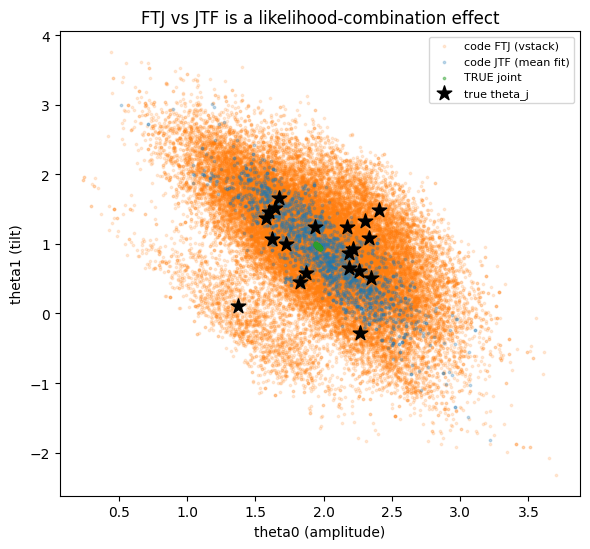

In [7]:
fig, axx = plt.subplots(figsize=(6,5.6))
axx.scatter(chain_ftj[::40,0], chain_ftj[::40,1], s=3, alpha=.15, color="tab:orange", label="code FTJ (vstack)")
axx.scatter(chain_jtf[::40,0], chain_jtf[::40,1], s=3, alpha=.25, color="tab:blue",   label="code JTF (mean fit)")
axx.scatter(chain_jnt[::40,0], chain_jnt[::40,1], s=3, alpha=.45, color="tab:green",  label="TRUE joint")
axx.scatter(theta_true[:,0], theta_true[:,1], marker="*", s=120, color="k", zorder=5, label="true theta_j")
axx.set_xlabel("theta0 (amplitude)"); axx.set_ylabel("theta1 (tilt)"); axx.legend(fontsize=8)
axx.set_title("FTJ vs JTF is a likelihood-combination effect"); plt.tight_layout(); plt.show()

**Read‑off.**
1. **`PAPER FTJ / TRUE joint ≈ √N_c`** — the `1/N_c` factor widens the posterior by √N_c; the printed FTJ is
   *not* the joint posterior.
2. **`code JTF / TRUE joint ≈ (1/σ)·√N_c`** — the unit‑variance bug inflates every width by `1/σ` (~10× at
   σ=0.1); absolute contour sizes are uncalibrated.
3. **code FTJ width ≈ √(population² + per‑fit²)** — the vstack is a *naive stack*: population scatter
   convolved with measurement scatter, so it **over‑estimates** the spread. The right tool is a hierarchical
   model (last section).

## 6. (Optional) The same on the real NFW model

If Colossus is installed, the identical comparison on the real forward model gives the **same** √N_c result —
confirming it isn't a toy artifact. (Reduced size to keep it quick.)

In [8]:
try:
    from colossus.cosmology import cosmology; from colossus.halo import profile_nfw
    cosmology.setCosmology('planck18')                       # repo simulations/__init__.py:3
    RB = 10**np.arange(0,3,0.1)
    def nfw_fwd(t): return np.log10(profile_nfw.NFWProfile(M=10**t[0], c=t[1], z=0.0, mdef='vir').density(RB))
    global forward; _save = forward; forward = nfw_fwd
    nb_walk = dict(NWALKERS=NWALKERS)
    Nc2, sig2 = 6, 0.3
    mt = 14.2+0.08*np.random.randn(Nc2); ct = 5.0+0.5*np.random.randn(Nc2)
    dat = np.array([nfw_fwd([mt[j],ct[j]]) + sig2*np.random.randn(len(RB)) for j in range(Nc2)])
    P = {'min_log10mass':10,'max_log10mass':18,'min_concentration':0.5,'max_concentration':30}
    cj = run_mcmc(np.mean(dat,axis=0,keepdims=True), P, starts=np.array([14.2,5.0])).flatchain
    cf = np.vstack([run_mcmc(d, P, starts=np.array([14.2,5.0])).flatchain for d in dat])
    lp_pr = lambda p,m,s: -0.5*np.sum((nfw_fwd(p)-m)**2/s**2)
    inb = lambda p: 10<p[0]<18 and 0.5<p[1]<30
    def rc(lp):
        s=emcee.EnsembleSampler(NWALKERS,2,lp); p0=np.array([14.2,5.0])+np.array([.05,.3])*np.random.randn(NWALKERS,2)
        pos,_,_=s.run_mcmc(p0,150,progress=False); s.reset(); s.run_mcmc(pos,400,progress=False); return s.get_chain(flat=True)
    jn = rc(lambda p: sum(lp_pr(p,d,sig2) for d in dat) if inb(p) else -np.inf)
    pa = rc(lambda p: (1/Nc2)*sum(lp_pr(p,d,sig2) for d in dat) if inb(p) else -np.inf)
    f=lambda c: np.std(c[:,0])
    print("REAL NFW (N_c=%d): code FTJ/JTF = %.2f | PAPER FTJ/TRUE joint = %.2f (sqrt Nc=%.2f)"
          % (Nc2, f(cf)/f(cj), f(pa)/f(jn), np.sqrt(Nc2)))
    forward = _save
except Exception as e:
    print("Colossus not available or run skipped:", e)

REAL NFW (N_c=6): code FTJ/JTF = 1.06 | PAPER FTJ/TRUE joint = 2.41 (sqrt Nc=2.45)


## 7. The fix — hierarchical inference by posterior **reuse**

Population model $m_j\sim\mathcal N(\mu,\tau^2)$, data $d_j\mid m_j\sim\mathcal N(m_j,\sigma^2)$. The
hyper‑posterior is $p(\Lambda\mid\{d_j\})\propto p(\Lambda)\prod_j p(d_j\mid\Lambda)$ with
$p(d_j\mid\Lambda)=\int p(d_j\mid\theta)p(\theta\mid\Lambda)\,d\theta$.

**Reuse identity:** with stored samples $\theta^s\sim p(\theta\mid d_j)\propto p(d_j\mid\theta)\pi(\theta)$,
$$p(d_j\mid\Lambda)\approx\frac{Z_j}{S}\sum_s\frac{p(\theta^s\mid\Lambda)}{\pi(\theta^s)}\;\xrightarrow{\;\pi\text{ flat}\;}\;\propto\frac1S\sum_s p(\theta^s\mid\Lambda).$$
So we recover $(\mu,\tau)$ by **reweighting stored per‑cluster samples** — no new per‑cluster likelihood
calls. We validate reuse **(B)** against the **exact analytic hyper-posterior (C)** --- the true reference ---
and contrast with the full joint MCMC **(A)** (correct but expensive in $2{+}N_c$ dims) and naive pooling.

In [9]:
np.random.seed(7)
N, sg, MU, TAU = 60, 0.30, 14.20, 0.30
mtru = MU + TAU*np.random.randn(N); d1 = mtru + sg*np.random.randn(N)
S = 4000
post = np.array([d1[j] + sg*np.random.randn(S) for j in range(N)])   # per-cluster posteriors (flat prior)

# (C) EXACT analytic hyper-posterior on a (mu, log tau) grid  -- the ground truth
mu_g = np.linspace(d1.mean()-0.4, d1.mean()+0.4, 300); lt_g = np.linspace(np.log(0.05), np.log(1.5), 300)
GM, GL = np.meshgrid(mu_g, lt_g, indexing='ij'); GT = np.exp(GL); gv = sg**2 + GT**2
lp = -0.5*np.sum((d1[:,None,None]-GM[None])**2/gv[None] + np.log(2*np.pi*gv)[None], axis=0)
Pg = np.exp(lp-lp.max()); Pg /= Pg.sum()
muC = float(np.sum(GM*Pg)); tauC = float(np.sum(GT*Pg))

# (B) importance-sampling reuse: L(mu,tau) = prod_j mean_s N(theta^s | mu, tau)   [cheap]
def lph(p):
    mu, lt = p; tau = np.exp(lt)
    if tau > 5: return -np.inf
    return sum(np.log(np.mean(np.exp(-0.5*((post[j]-mu)/tau)**2)/tau)+1e-300) for j in range(N)) + lt
sB = emcee.EnsembleSampler(10, 2, lph); p0=np.column_stack([MU+.1*np.random.randn(10), np.log(.3)+.1*np.random.randn(10)])
pos,_,_ = sB.run_mcmc(p0,1200,progress=False); sB.reset(); sB.run_mcmc(pos,3000,progress=False)
B = sB.get_chain(flat=True); muB, tauB = B[:,0], np.exp(B[:,1])

# (A) full joint hierarchical MCMC over (mu, log tau, m_1..m_N)   [correct but expensive in 2+N dims]
def lpj(p):
    mu, lt, m = p[0], p[1], p[2:]; tau = np.exp(lt)
    if tau > 5: return -np.inf
    return (-0.5*np.sum(((d1-m)/sg)**2)) + (-0.5*np.sum(((m-mu)/tau)**2) - N*lt) + lt
nd = 2+N; nw = 2*nd
p0 = np.column_stack([MU+0.1*np.random.randn(nw), np.log(.3)+0.1*np.random.randn(nw), d1[None,:]+0.1*np.random.randn(nw,N)])
sA = emcee.EnsembleSampler(nw, nd, lpj); pos,_,_ = sA.run_mcmc(p0,1500,progress=False); sA.reset(); sA.run_mcmc(pos,4000,progress=False)
A = sA.get_chain(flat=True); muA, tauA = A[:,0], np.exp(A[:,1])

pooled = post.ravel()
print("truth:               mu=%.3f tau=%.3f" % (MU,TAU))
print("(C) EXACT analytic : mu=%.3f tau=%.3f   <- ground truth" % (muC, tauC))
print("(B) reuse          : mu=%.3f tau=%.3f   <- matches C, cheap" % (muB.mean(), tauB.mean()))
print("(A) full joint MCMC: mu=%.3f tau=%.3f   <- correct but expensive (2+N dims)" % (muA.mean(), tauA.mean()))
print("naive pool         : mu=%.3f tau=%.3f   <- biased ~sqrt(tau^2+2 sig^2)=%.3f" % (pooled.mean(), pooled.std(), np.sqrt(TAU**2+2*sg**2)))
print("VALIDATION |B - C| : d_mu=%.4f d_tau=%.4f   (reuse vs exact = the real test)" % (abs(muB.mean()-muC), abs(tauB.mean()-tauC)))

truth:               mu=14.200 tau=0.300
(C) EXACT analytic : mu=14.219 tau=0.329   <- ground truth
(B) reuse          : mu=14.217 tau=0.337   <- matches C, cheap
(A) full joint MCMC: mu=14.220 tau=0.369   <- correct but expensive (2+N dims)
naive pool         : mu=14.218 tau=0.535   <- biased ~sqrt(tau^2+2 sig^2)=0.520
VALIDATION |B - C| : d_mu=0.0010 d_tau=0.0079   (reuse vs exact = the real test)


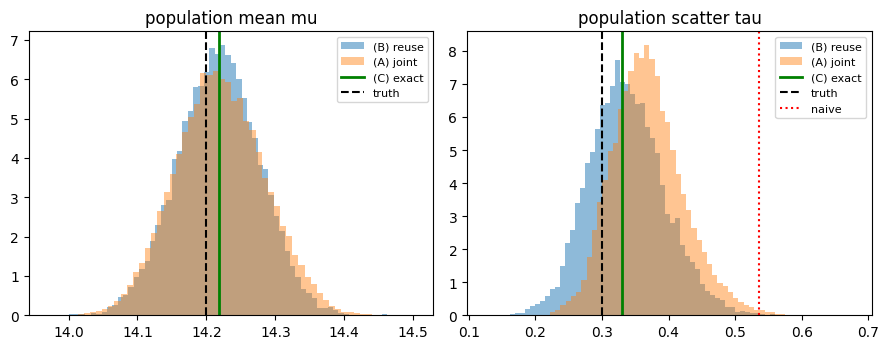

In [10]:
fig, a2 = plt.subplots(1,2,figsize=(9,3.6))
a2[0].hist(muB,60,density=True,alpha=.5,label="(B) reuse"); a2[0].hist(muA,60,density=True,alpha=.45,label="(A) joint")
a2[0].axvline(muC,color="g",lw=2,label="(C) exact"); a2[0].axvline(MU,color="k",ls="--",label="truth")
a2[0].set_title("population mean mu"); a2[0].legend(fontsize=8)
a2[1].hist(tauB,60,density=True,alpha=.5,label="(B) reuse"); a2[1].hist(tauA,60,density=True,alpha=.45,label="(A) joint")
a2[1].axvline(tauC,color="g",lw=2,label="(C) exact"); a2[1].axvline(TAU,color="k",ls="--",label="truth"); a2[1].axvline(pooled.std(),color="r",ls=":",label="naive")
a2[1].set_title("population scatter tau"); a2[1].legend(fontsize=8); plt.tight_layout(); plt.show()

## Summary

- The FTJ↔JTF gap is **likelihood‑combination math**, reproduced with a toy model and on real NFW.
- The printed FTJ `1/N_c` widens the posterior by **√N_c** vs the correct joint fit.
- The code's unit‑variance likelihood makes posteriors **~1/σ too wide** (uncalibrated absolute contours).
- "FTJ captures the distribution" is a **naive stack** (population ⊕ measurement) — biased high.
- The principled fix — **importance‑sampling reuse** of per‑cluster posteriors — recovers the population
  hyperparameters and matches the EXACT analytic hyper-posterior (cheaply; the full joint MCMC is the costly
  path). This is the starting point for the HBI project.

*Next:* swap the toy Gaussian per‑cluster posteriors in §7 for Akum's actual SBI `DirectPosterior` samples.